In [3]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

# sys.path.append(os.path.expanduser('~/git/desi-examples/misc/plot_spectrum/'))
# import desi_plot_spectrum

In [15]:
def get_rr_model(coadd_fn, redrock_fn, index, use_targetid=False, restframe=False, z=None, return_z=False):
    '''
    Return redrock model spectrum.

    Args:
       coadd_fn: str, path of coadd FITS file
       index: int, index of coadd FITS file if use_targetid=False, or TARGETID if use_targetid=True

    Options:
       use_targetid: bool, if True, index is TARGETID
       restframe: bool, if True, return restframe spectrum in template wavelength grid; if False,
       return spectrum in three cameras in observed frame
       z: bool, if None, use redrock best-fit redshift
       return_z: bool, if true, include redshift in output
    '''
    # If use_targetid=False, index is the index of coadd file; if True, index is TARGETID.

    from desispec.interpolation import resample_flux
    import redrock.templates
    from desispec.io import read_spectra

    spec = read_spectra(coadd_fn)
    redshifts = Table(fitsio.read(redrock_fn, ext='REDSHIFTS'))

    if use_targetid:
        coadd_index = np.where(redshifts['TARGETID']==index)[0][0]
    else:
        coadd_index = index
    if z is None:
        z = redshifts['Z'][coadd_index]

    templates = dict()
    for filename in redrock.templates.find_templates():
        tx = redrock.templates.Template(filename)
        templates[(tx.template_type, tx.sub_type)] = tx

    tx = templates[(redshifts['SPECTYPE'][coadd_index], redshifts['SUBTYPE'][coadd_index])]
    coeff = redshifts['COEFF'][coadd_index][0:tx.nbasis]

    if restframe==False:
        wave = dict()
        model_flux = dict()
        camera = 'BRZ'
        wave[camera] = spec.wave[camera.lower()]
        model_flux[camera] = np.zeros(wave[camera].shape)
        model = tx.flux.T.dot(coeff).T
        mx = resample_flux(wave[camera], tx.wave*(1+z), model)
        model_flux[camera] = spec.R[camera.lower()][coadd_index].dot(mx)
    else:
        wave = tx.wave
        model_flux = tx.flux.T.dot(coeff).T

    if return_z:
        return wave, model_flux, z
    else:
        return wave, model_flux


def plot_spectrum(coadd_fn, redrock_fn, index, use_targetid=False, show_lines=True, show_restframe=True, show_model=True,
    figsize=(20, 8), lw=1.2, gauss_smooth=3, label=None, title=None, show=True, return_ax=False,
    xlim=[3400, 10000], ylim=None):
    '''
    Plot DESI spectrum.

    Args:
       coadd_fn: str, path of coadd FITS file
       index: int, index of coadd FITS file if use_targetid=False, or TARGETID if use_targetid=True
       
    Options:
       use_targetid: bool, if True, index is TARGETID
    '''

    from astropy.convolution import Gaussian1DKernel, convolve

    lines = {
        'Ha'      : 6562.8,
        'Hb'       : 4862.68,
        'Hg'       : 4340.464,
        'Hd'       : 4101.734,
        # 'OIII-b'       :  5006.843,
        # 'OIII-a'       : 4958.911,
        'OIII': 4982.877,
        'MgII'    : 2799.49,
        'OII'         : 3728,
        'CIII'  : 1909.,
        'CIV'    : 1549.06,
        'SiIV'  : 1393.76018,
        'LYA'         : 1215.67,
        'LYB'         : 1025.72
    }

    tmp = fitsio.read(coadd_fn, columns=['TARGETID'], ext='FIBERMAP')

    if use_targetid:
        tid = index
        coadd_index = np.where(tmp['TARGETID']==index)[0][0]
    else:
        tid = tmp['TARGETID'][index]
        coadd_index = index

    if show_model:
        # Get model spectrum
        _, model_flux = get_rr_model(coadd_fn, redrock_fn, coadd_index)

    redshifts = Table(fitsio.read(redrock_fn, ext='REDSHIFTS'))
    z = redshifts['Z'][coadd_index]
        
    fig, ax1 = plt.subplots(figsize=figsize)
    camera = 'BRZ'
    wave = fitsio.read(coadd_fn, ext=camera+'_WAVELENGTH')
    # wave_rest = wave/(1+z)
    flux = fitsio.read(coadd_fn, ext=camera+'_FLUX')[coadd_index]
    mask = fitsio.read(coadd_fn, ext=camera+'_MASK')[coadd_index]
    flux[mask] = np.nan
    if np.sum(mask!=0)!=0:
        print('{} masked pixels: {}'.format(camera, np.sum(mask!=0)))

    if gauss_smooth==0 or gauss_smooth is None:
        flux_smooth = flux.copy()
    elif gauss_smooth>0:
        gauss_kernel = Gaussian1DKernel(stddev=gauss_smooth)
        flux_smooth = convolve(flux, gauss_kernel)

    if label is not None:
        plot_label = label
    else:
        plot_label = 'TID={}\nZ={:.4f}  TYPE={}  ZWARN={}  DELTACHI2={:.1f}'.format(tid, z, redshifts['SPECTYPE'][coadd_index], redshifts['ZWARN'][coadd_index], redshifts['DELTACHI2'][coadd_index])

    ax1.plot(wave, flux_smooth, lw=lw, label=plot_label)
    if show_model:
        if gauss_smooth==0 or gauss_smooth is None:
            model_flux_smooth = model_flux[camera].copy()
        elif gauss_smooth>0:
            model_flux_smooth = convolve(model_flux[camera], gauss_kernel)
        ax1.plot(wave, model_flux_smooth, lw=lw, color='r', alpha=0.65)

    if show_lines:
        for line in lines.keys():
            if (lines[line]*(1+z)>3400) & (lines[line]*(1+z)<10000):
                ax1.axvline(lines[line]*(1+z), lw=lw, color='r', alpha=0.3)
                ax1.text(lines[line]*(1+z), -0.8, line)
    if ylim is None:
        ylim = [-1, 1.3*np.percentile(flux_smooth, 99.)]
    ax1.axis([xlim[0], xlim[1], ylim[0], ylim[1]])
    ax1.set_xlabel('observed wavelength ($\AA$)')
    # plt.axvline(4000, ls='--', lw=1, color='k')
    ax1.legend(loc='upper left', handletextpad=.0, handlelength=0)
    ax1.grid()
    if title is not None:
        ax1.set_title(title)
    if show_restframe:
        ax2 = ax1.twiny()
        ax2.set_xlim(3400/(1+z), 10000/(1+z))
        ax2.set_xlabel('restframe wavelength ($\AA$)')
    plt.tight_layout()
    # plt.savefig('/global/cfs/cdirs/desi/users/rongpu/plots/lrg_speed/spectra_low_speed_failures/{}_deep.png'.format(tid))
    if show:
        plt.show()

    if return_ax:
        if show_restframe:
            return ax1, ax2
        else:
            return ax1


# coadd_fn = '/global/cfs/cdirs/desi/spectro/redux/everest/tiles/cumulative/80605/20210205/coadd-0-80605-thru20210205.fits'
# tid = 39627640566453451
# plot_spectrum(coadd_fn, tid, use_targetid=True)


In [5]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [6]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/main_cumulative_lrg.fits'))
print(len(cat))

# cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove duplidates keeping the higher EFFTIME objects
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))

mask = cat['TILEID']==1242
cat = cat[mask]
print(len(cat))

345431
FIBERSTATUS 338266 7165 0.020742203218587794
No data 338265 1 2.9562533627382e-06
LRG mask 304337 33928 0.1003000606033731
Remove QSO targets 299639 4698 0.015436834824553046
299639 299609 30
299609 299609 0
1121


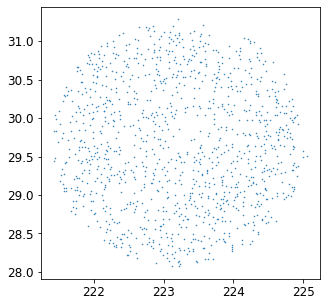

In [7]:
plt.figure(figsize=(5, 5))
plt.plot(cat['TARGET_RA'], cat['TARGET_DEC'], '.', ms=1)
plt.show()

In [8]:
np.random.seed(706846)
idx = np.random.choice(len(cat), size=6, replace=False)
cat1 = cat[idx].copy()
cat1.sort('Z')

In [9]:
cat1

TARGETID,Z,ZERR,ZWARN,CHI2,SPECTYPE,SUBTYPE,DELTACHI2,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,COADD_FIBERSTATUS,TARGET_RA,TARGET_DEC,FIBERASSIGN_X,FIBERASSIGN_Y,MORPHTYPE,EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FIBERFLUX_Z,MASKBITS,PARALLAX,PHOTSYS,DESI_TARGET,BGS_TARGET,TILEID,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,TSNR2_ELG,TSNR2_BGS,TSNR2_QSO,TSNR2_LRG,LASTNIGHT,fn,lrg_mask,EFFTIME_LRG
int64,float64,float64,int64,float64,str6,str20,float64,int16,int32,int64,int32,int32,float64,float64,float32,float32,str4,float32,float32,float32,float32,float32,float32,float32,int16,float32,str1,int64,int64,int32,int16,float32,int16,int16,float32,float32,float32,float32,int64,str73,int16,float32
39628454982847889,0.44094522576819356,6.220688654413627e-05,0,7765.869073398411,GALAXY,,630.8505760654807,1,456,1456,589,0,222.04768206728872,28.66754989997653,254.84169,-254.19621,SER,0.017555593,3.7415066,18.794193,45.471516,82.126625,50.721924,11.339495,0,0.0,S,1152921504606912513,131074,1242,1,727.0249,1,1,111.07207,6615.74,29.19519,84.45732,20210606,guadalupe/tiles/cumulative/1242/20210606/redrock-1-1242-thru20210606.fits,0,1026.1564
39628486574343773,0.45486008183499266,7.208424685931258e-05,0,7914.794577330351,GALAXY,,411.3465921655297,3,190,3190,1726,0,222.2590873734419,30.18790565143422,201.93565,125.2905,DEV,0.018278547,1.8415605,9.085032,23.026577,55.00444,38.507355,8.424659,0,0.0,S,1152921504606912513,65537,1242,1,727.0249,1,1,118.92697,7017.2334,32.193634,86.747314,20210606,guadalupe/tiles/cumulative/1242/20210606/redrock-3-1242-thru20210606.fits,0,1053.9799
39628444367065174,0.5503009907219634,6.444740115706941e-05,0,7889.902559638023,GALAXY,,430.7368099875748,0,492,492,387,0,223.04992193704763,28.174956033495715,33.85477,-380.43134,DEV,0.02131385,2.7702572,9.991794,25.099993,59.24818,36.009853,7.428676,0,0.0,S,1152921504606912513,65537,1242,1,727.0249,1,1,114.606224,6490.9053,29.859632,82.32326,20210606,guadalupe/tiles/cumulative/1242/20210606/redrock-0-1242-thru20210606.fits,0,1000.22754
39628476109558143,0.7986295433147697,8.425940900598187e-05,0,7674.505189731717,GALAXY,,87.05909146368504,7,2,7002,3971,0,223.39475401412423,29.711916904836183,-40.059006,7.36762,REX,0.020686986,0.1490147,0.67210084,3.4932303,14.824179,7.6496463,2.3866177,0,0.0,S,65537,0,1242,1,727.0249,1,1,128.83781,7161.2236,34.85375,87.925125,20210606,guadalupe/tiles/cumulative/1242/20210606/redrock-7-1242-thru20210606.fits,0,1068.2903
39628476117946347,0.8843631963716598,0.00011951054009981249,0,7574.912695258856,GALAXY,,180.3571785017848,7,96,7096,3745,0,223.9838560817886,29.857952342549304,-165.37198,43.92959,REX,0.02056031,0.14531025,1.1172633,6.335754,33.228016,20.805876,3.0804694,0,0.0,S,65537,0,1242,1,727.0249,1,1,136.8297,7777.9077,37.21048,97.09776,20210606,guadalupe/tiles/cumulative/1242/20210606/redrock-7-1242-thru20210606.fits,0,1179.7378
39628444367065365,1.0868039731227526,7.466139796677025e-05,0,7741.723458379507,GALAXY,,150.37652392312884,0,387,387,196,0,223.05880197751614,28.352710277187036,31.62388,-332.70673,REX,0.019284258,0.46231225,1.079061,5.5367203,31.82575,26.996788,2.595665,0,0.0,S,65537,0,1242,1,727.0249,1,1,103.816475,5999.9004,26.933414,74.84644,20210606,guadalupe/tiles/cumulative/1242/20210606/redrock-0-1242-thru20210606.fits,0,909.3843


INFO:spectra.py:285:read_spectra: iotime 9.727 sec to read coadd-1-1242-thru20210606.fits at 2022-03-03T15:17:00.640270
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate

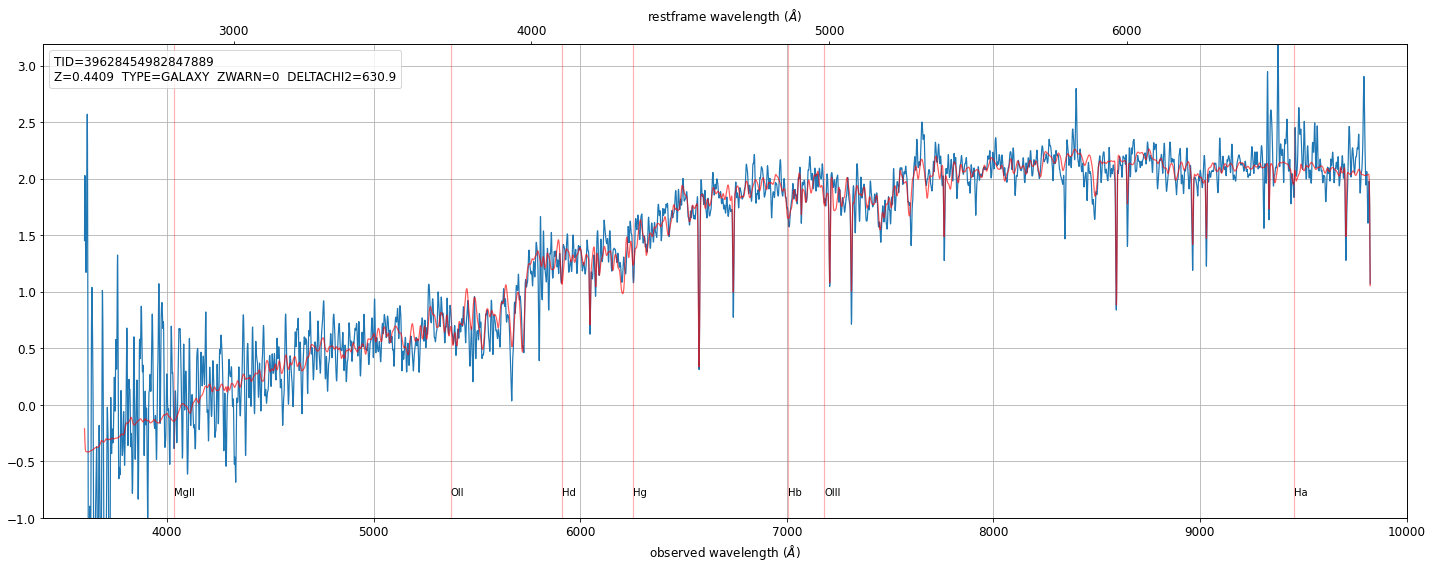

INFO:spectra.py:285:read_spectra: iotime 0.681 sec to read coadd-3-1242-thru20210606.fits at 2022-03-03T15:17:10.618894
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate

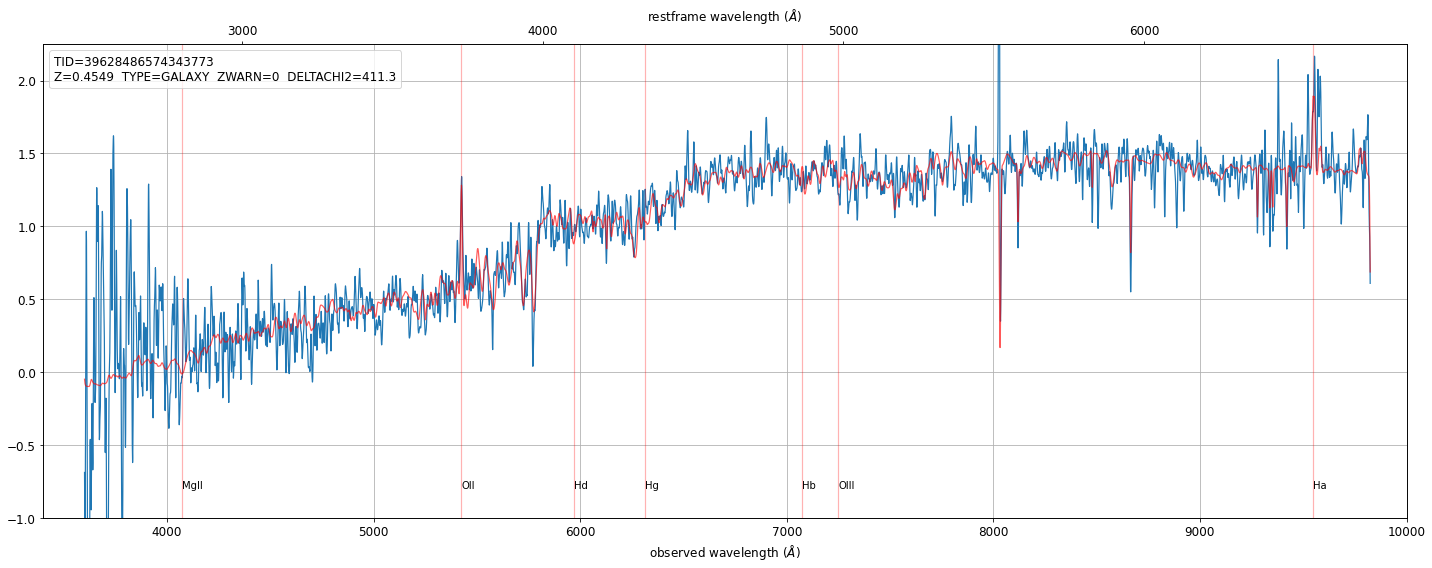

INFO:spectra.py:285:read_spectra: iotime 13.168 sec to read coadd-0-1242-thru20210606.fits at 2022-03-03T15:17:25.150204
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplat

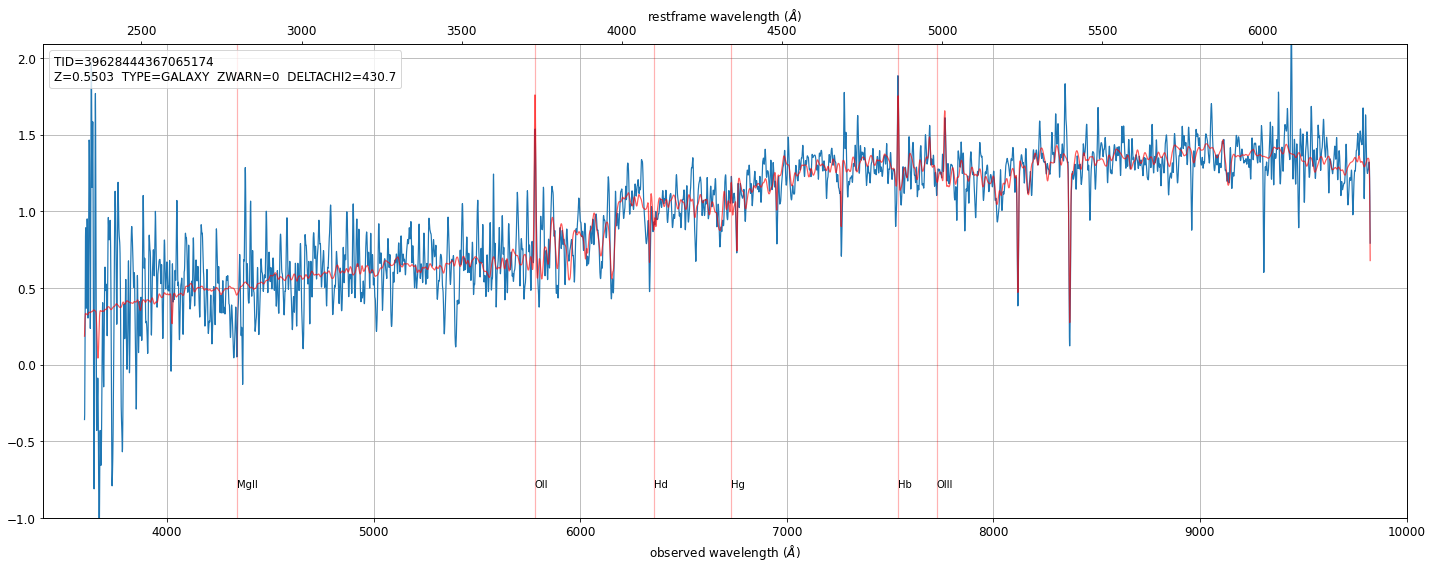

INFO:spectra.py:285:read_spectra: iotime 1.011 sec to read coadd-7-1242-thru20210606.fits at 2022-03-03T15:17:32.996816
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate

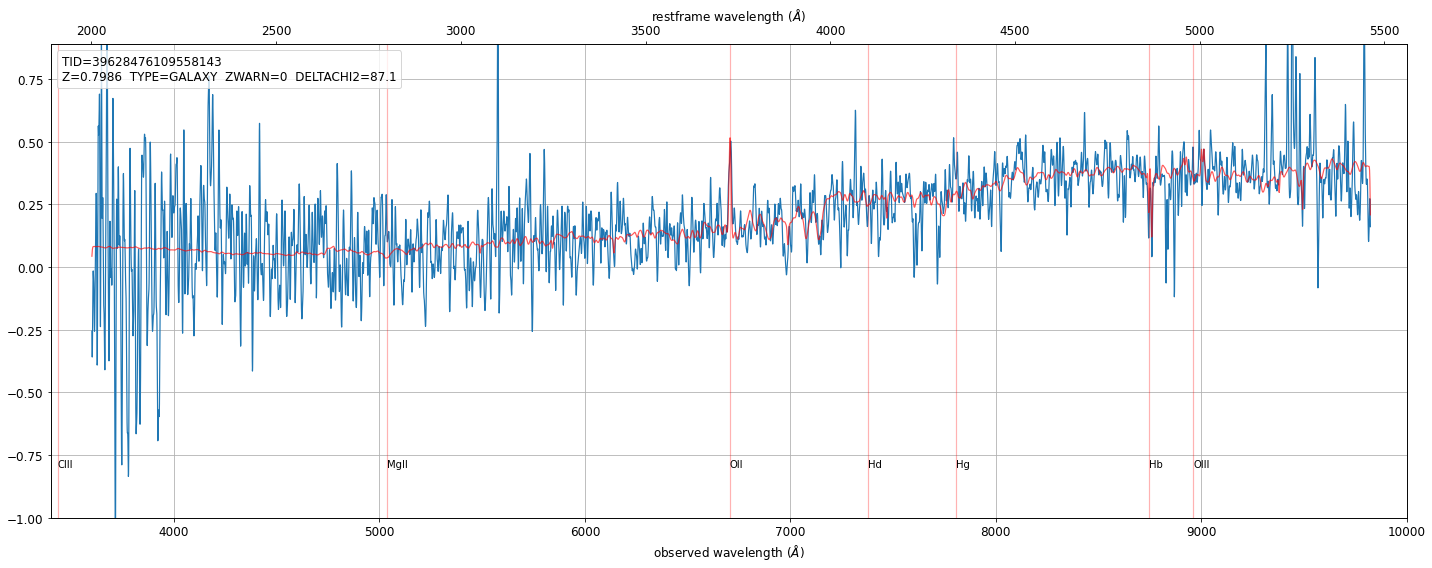

INFO:spectra.py:285:read_spectra: iotime 0.752 sec to read coadd-7-1242-thru20210606.fits at 2022-03-03T15:17:38.403733
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate

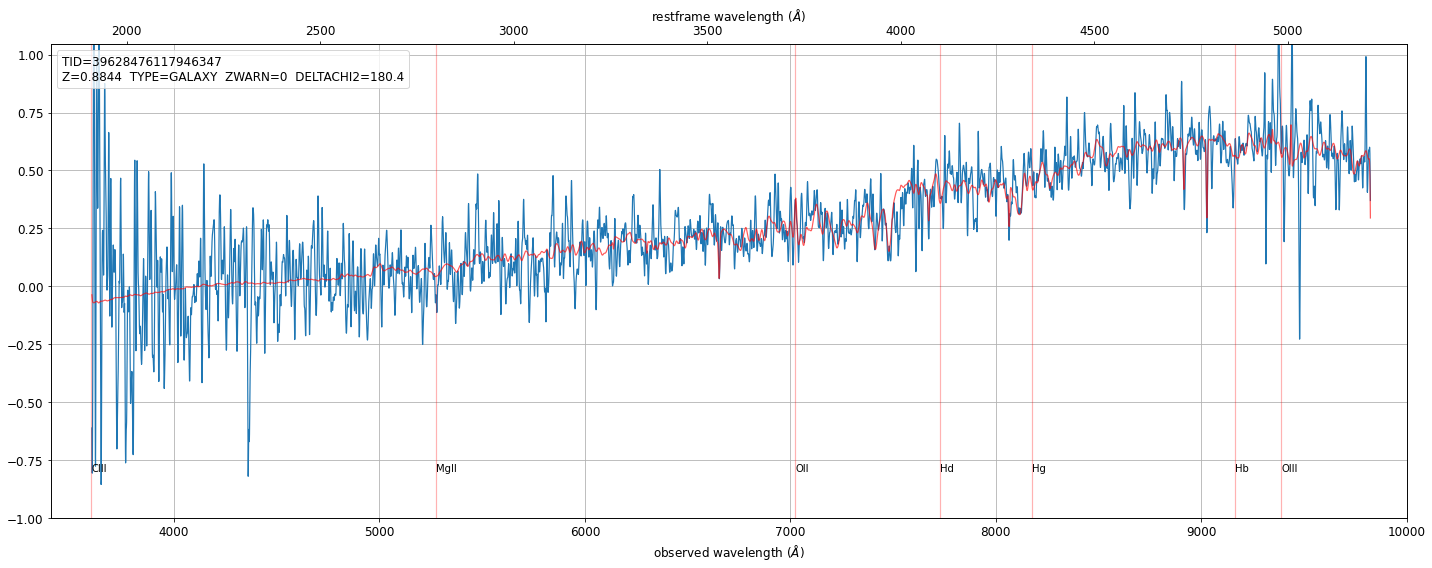

INFO:spectra.py:285:read_spectra: iotime 0.646 sec to read coadd-0-1242-thru20210606.fits at 2022-03-03T15:17:40.818652
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate

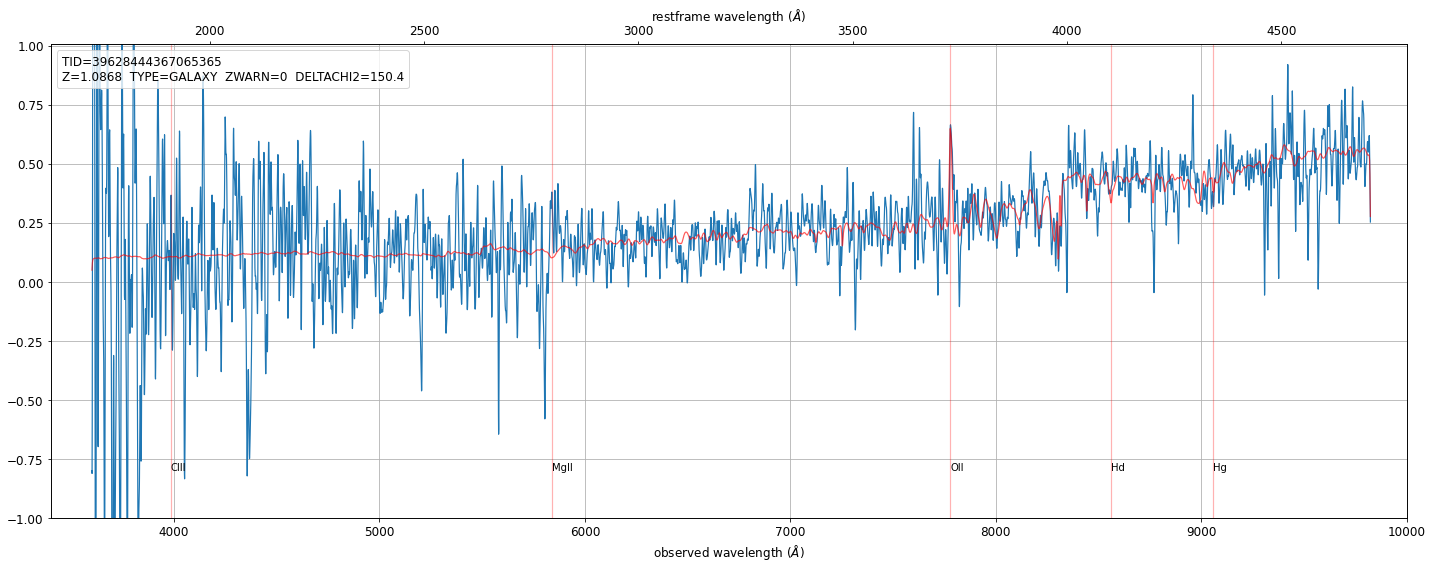

In [12]:
for index in range(len(cat1)):
    coadd_fn = '/global/cfs/cdirs/desi/users/rongpu/data/lrg/example_spectra/'+os.path.basename(cat1['fn'][index]).replace('redrock', 'coadd')
    redrock_fn = '/global/cfs/cdirs/desi/spectro/redux/'+cat1['fn'][index]
    plot_spectrum(coadd_fn, redrock_fn, cat1['TARGETID'][index], use_targetid=True)

INFO:spectra.py:285:read_spectra: iotime 70.920 sec to read coadd-1-1242-thru20210606.fits at 2022-03-03T15:34:07.060810
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplat

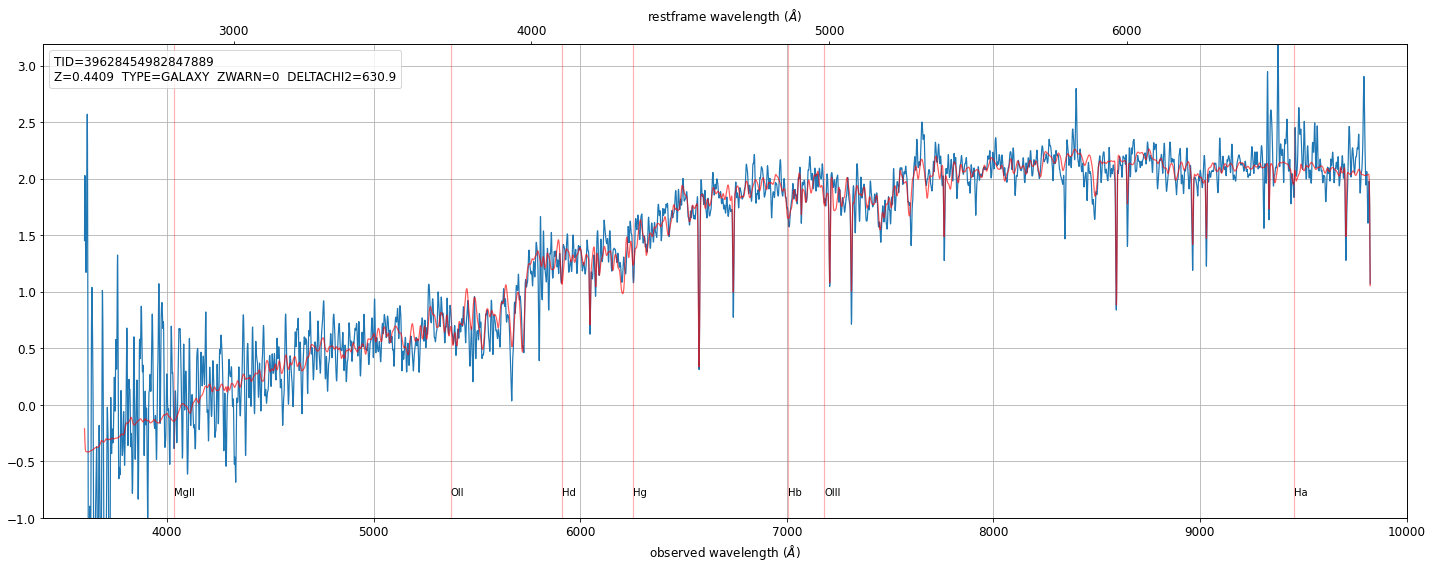

INFO:spectra.py:285:read_spectra: iotime 24.665 sec to read coadd-3-1242-thru20210606.fits at 2022-03-03T15:35:08.787949
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplat

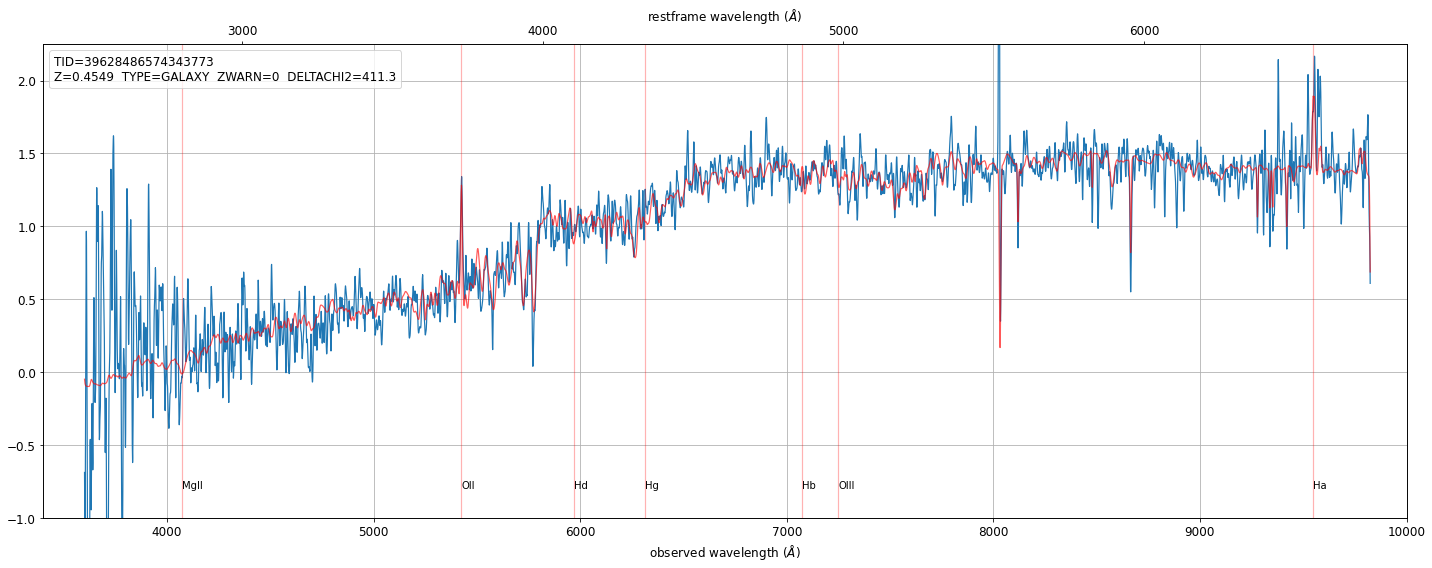

INFO:spectra.py:285:read_spectra: iotime 23.951 sec to read coadd-0-1242-thru20210606.fits at 2022-03-03T15:35:58.233640
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplat

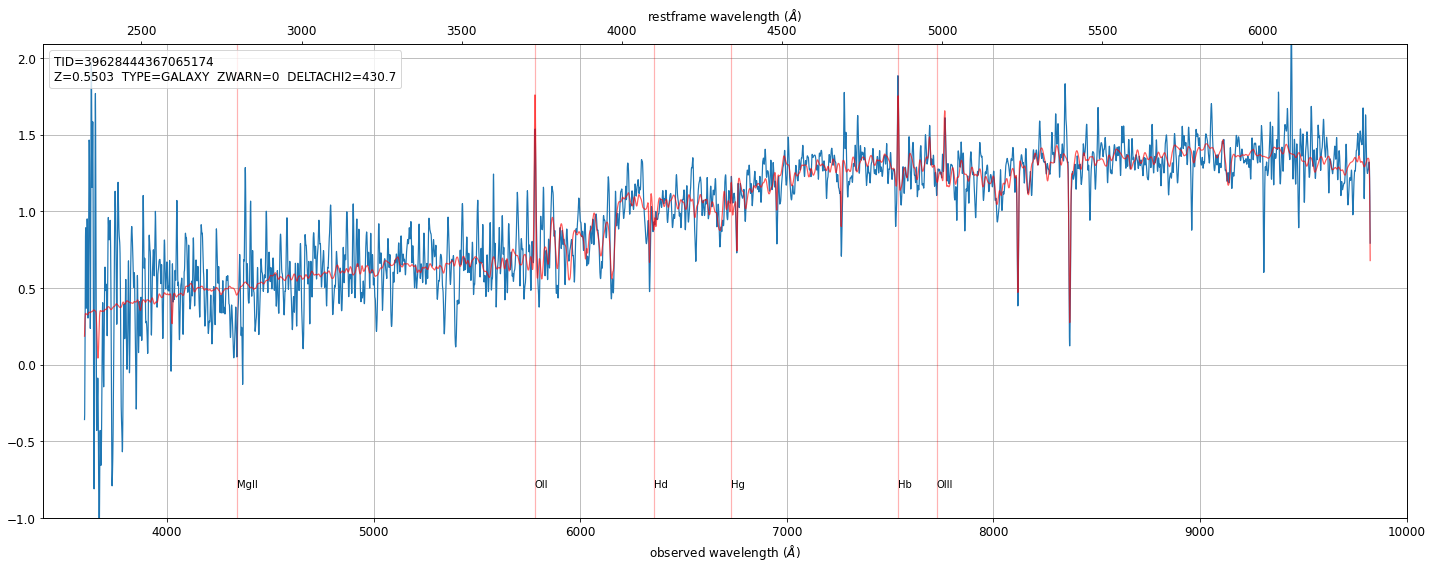

INFO:spectra.py:285:read_spectra: iotime 38.802 sec to read coadd-7-1242-thru20210606.fits at 2022-03-03T15:36:53.230755
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplat

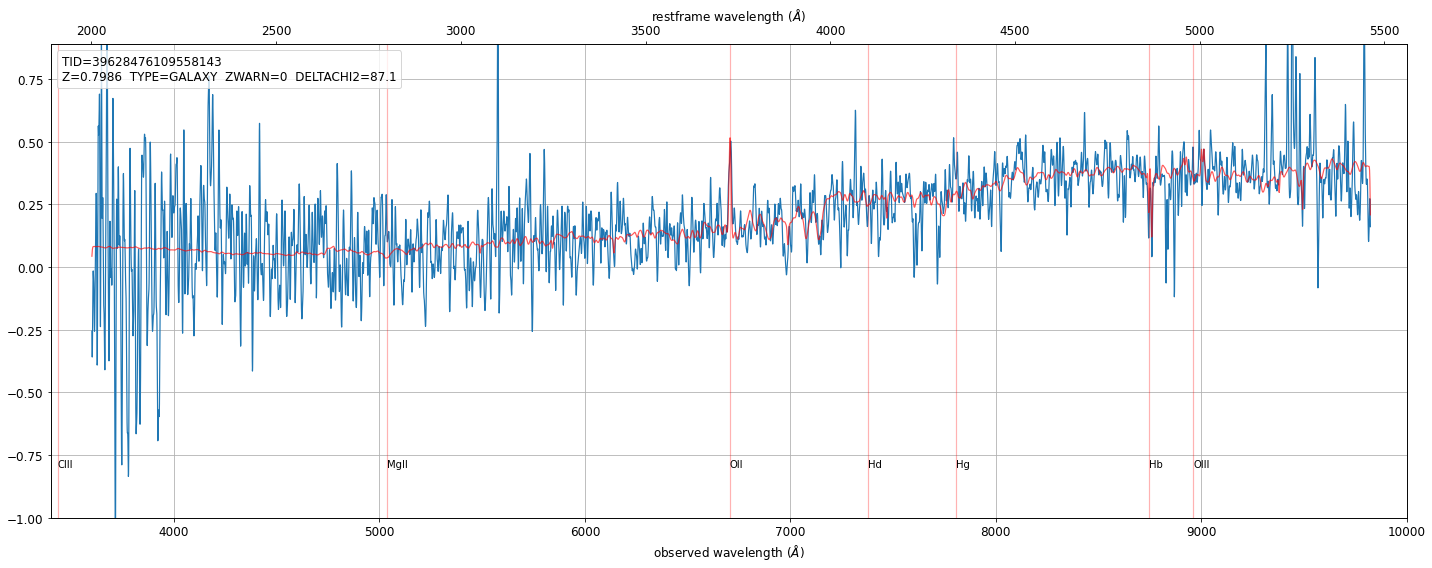

INFO:spectra.py:285:read_spectra: iotime 74.353 sec to read coadd-7-1242-thru20210606.fits at 2022-03-03T15:38:10.573987
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplat

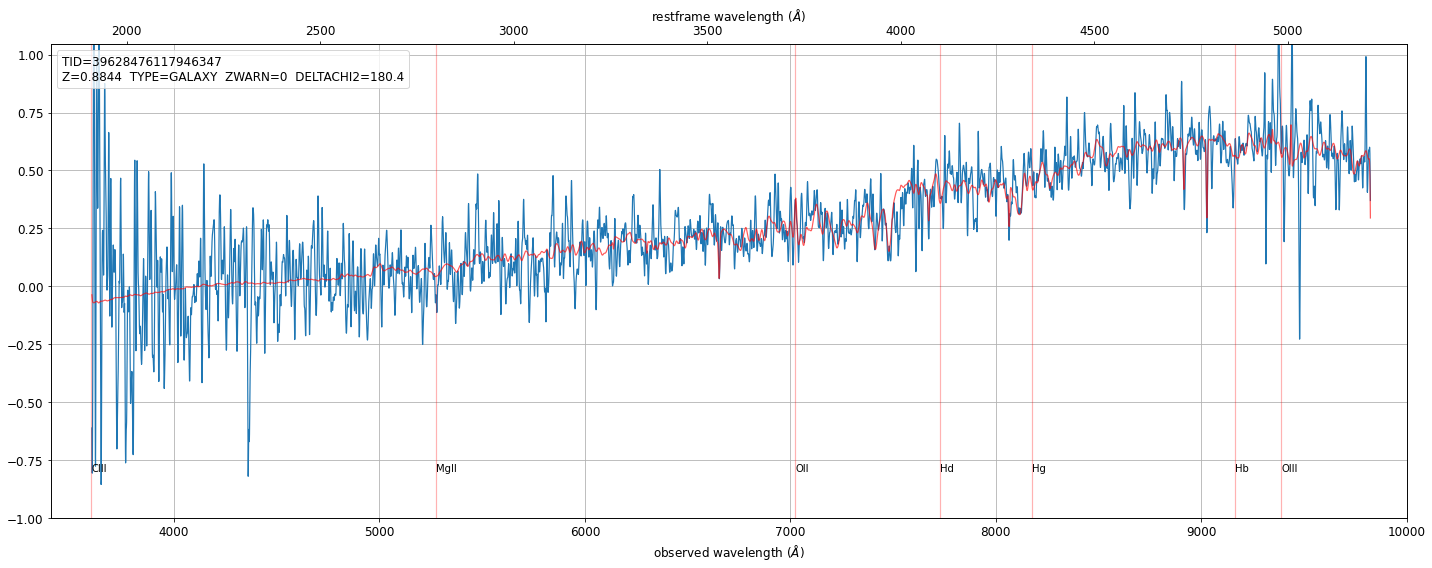

INFO:spectra.py:285:read_spectra: iotime 29.073 sec to read coadd-0-1242-thru20210606.fits at 2022-03-03T15:39:35.022024


In [ ]:
for index in range(len(cat1)):
    coadd_fn = '/global/cfs/cdirs/desi/users/rongpu/data/lrg/example_spectra/'+os.path.basename(cat1['fn'][index]).replace('redrock', 'coadd')
    redrock_fn = '/global/cfs/cdirs/desi/spectro/redux/'+cat1['fn'][index]
    plot_spectrum(coadd_fn, redrock_fn, cat1['TARGETID'][index], use_targetid=True)